In [3]:
import pysr


print(pysr.__version__)

1.5.9


Training Neural Network...
Epoch 0, Loss: 2053.433846
Epoch 1000, Loss: 899.912160
Epoch 2000, Loss: 886.337308
Epoch 3000, Loss: 866.255400
Epoch 4000, Loss: 839.911459
Neural Network Training Finished!
Valid samples: 200
Training PySR...


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.240e+05
Progress: 2447 / 6200 total iterations (39.468%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.148e+00  0.000e+00  y = 33.672
5           1.270e+00  2.270e-01  y = sqrt(square(x₀)) + 28.646
6           1.968e-01  1.864e+00  y = (square(x₀) * 0.057052) + 31.751
7           1.429e-04  7.228e+00  y = (sqrt(square(x₀)) * 0.6116) + 30.598
9           1.200e-04  8.724e-02  y = (sqrt(square(x₀ + -0.0078205)) * 0.61159) + 30.598
10          1.200e-04  2.193e-04  y = (sqrt((x₀ + -0.015676) * x₀) * 0.61159) + 30.598
12          1.199e-04  5.433e-04  y = (sqrt((x₀ + -0.03434) * (x₀ + 0.0186)) * 0.61154) + 30...
                                      .599
14          9.865e-06  1.249e+00  y = (sqrt(x₀ * (x₀ + -0.04648)) * ((x₀ * 0.00031216) + 0.6

[ Info: Final population:
[ Info: Results saved to:


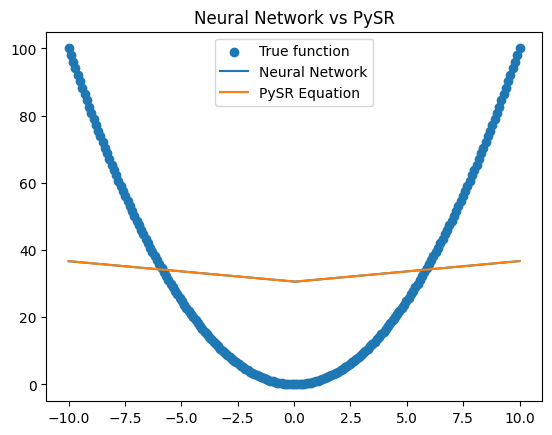


Test input: x=12
Neural Network output: 37.87432376639694
PySR output: 37.95900268607048


In [18]:
# =====================================================
# Neural Network + PySR Hybrid Symbolic Regression
# Stable version (No NaN, No crashes)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from pysr import PySRRegressor

# =====================================================
# STEP 1: Create dataset
# Example hidden function: y = x^2
# =====================================================

X = np.linspace(-10, 10, 200).reshape(-1, 1)
y_true = X.flatten()**2

# =====================================================
# STEP 2: Create stable Neural Network
# =====================================================

np.random.seed(42)

input_size = 1
hidden_size = 16
output_size = 1

# Safe weight initialization
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

# Activation function
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# Training settings
learning_rate = 0.0001
epochs = 5000

# =====================================================
# STEP 3: Train Neural Network
# =====================================================

print("Training Neural Network...")

for epoch in range(epochs):

    # Forward pass
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    y_pred = z2

    # Loss
    loss = np.mean((y_pred.flatten() - y_true)**2)

    # Backward pass
    dloss = 2 * (y_pred.flatten() - y_true).reshape(-1,1)

    dW2 = a1.T @ dloss
    db2 = np.sum(dloss, axis=0)

    da1 = dloss @ W2.T
    dz1 = da1 * relu_derivative(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0)

    # Gradient clipping (prevents explosion)
    clip_value = 1.0
    dW1 = np.clip(dW1, -clip_value, clip_value)
    dW2 = np.clip(dW2, -clip_value, clip_value)

    # Update weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

print("Neural Network Training Finished!")

# =====================================================
# STEP 4: Generate Neural Network predictions
# =====================================================

z1 = X @ W1 + b1
a1 = relu(z1)
nn_output = (a1 @ W2 + b2).flatten()

# Remove NaN and Inf safely
mask = np.isfinite(nn_output)

X_clean = X[mask]
y_clean = nn_output[mask]

print("Valid samples:", len(X_clean))

# =====================================================
# STEP 5: Train PySR on Neural Network outputs
# =====================================================

print("Training PySR...")

model = PySRRegressor(

    niterations=200,

    binary_operators=[
        "+",
        "-",
        "*",
        "/"
    ],

    unary_operators=[
        "square",
        "cube",
        "sqrt"
    ],

    maxsize=20,

    verbosity=1
)

model.fit(X_clean, y_clean)

print("PySR Training Finished!")

# =====================================================
# STEP 6: Show discovered equation
# =====================================================

equation = model.sympy()

print("\nDiscovered Equation:")
print("y =", equation)

# =====================================================
# STEP 7: Compare results
# =====================================================

pysr_pred = model.predict(X)

plt.figure()

plt.scatter(X, y_true, label="True function")

plt.plot(X, nn_output, label="Neural Network")

plt.plot(X, pysr_pred, label="PySR Equation")

plt.legend()

plt.title("Neural Network vs PySR")

plt.show()

# =====================================================
# STEP 8: Test prediction
# =====================================================

test = np.array([[12]])

nn_test = relu(test @ W1 + b1) @ W2 + b2
pysr_test = model.predict(test)

print("\nTest input: x=12")
print("Neural Network output:", nn_test[0][0])
print("PySR output:", pysr_test[0])



Processing function: x^2


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Discovered equation: 0.00514043*x0 + 0.404353743645338*sqrt(x0*(x0 - 0.024446191)) - 0.00514043*sin(0.9317557*x0 + 0.9317557*sin(x0)) + 7.4064546

Processing function: 3x+5


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Discovered equation: ((x0 + x0)*cos(0.00027728005/(x0 + 5.0030694))/0.90301025 + 5.0030694)*cos(-0.0001741834/(x0 - 1*5.003104))

Processing function: x^3+2x


...

Discovered equation: x0*0.09458534 - (-0.9574791)*x0 + x0 - 0.009672168

Processing function: sin(x)+x^2


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Discovered equation: sqrt((x0 - 0.7733763)**2 + (cos(1.2882589*x0) + 2.5064673)*cos(x0 - 2.1372616) + 4.377923) + 4.9781685

Processing function: log(|x|+1)+x^2


c:\Users\mohda\Desktop\MacLrn\.machine\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Discovered equation: 0.027774548*x0 + sqrt((0.94696605*x0 - 0.028076531)**2 + 4.043326e-6) + 7.2174735


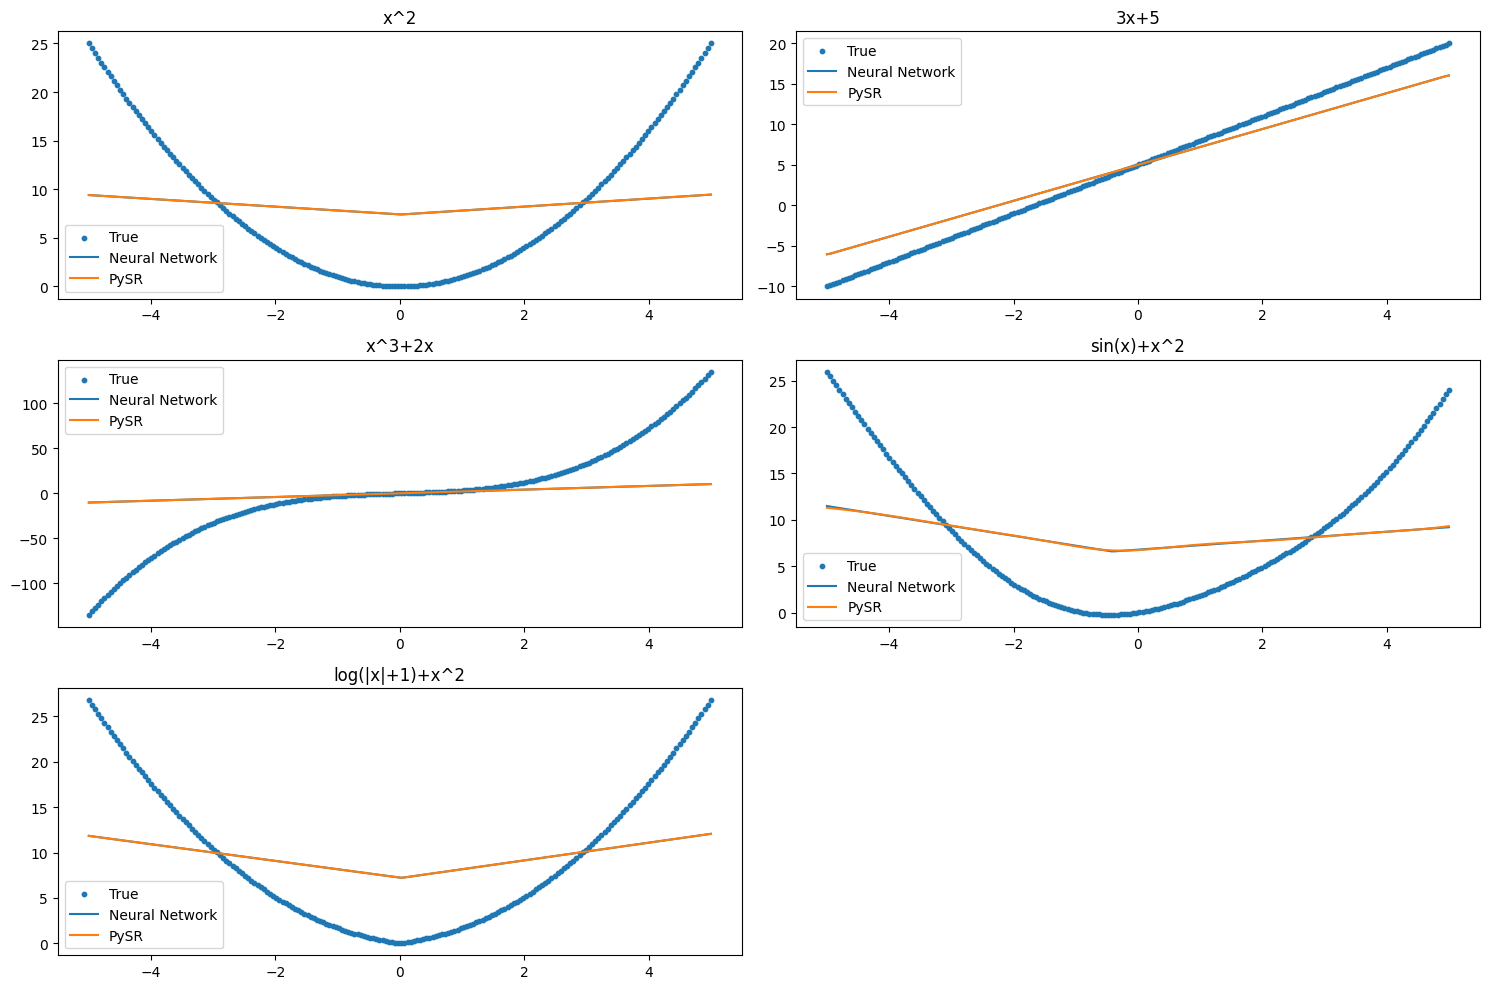

In [19]:
# ============================================================
# Multi-Function Neural Network + PySR Symbolic Discovery Lab
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pysr import PySRRegressor

np.random.seed(42)

# ============================================================
# Define functions to test
# ============================================================

def func1(x):
    return x**2

def func2(x):
    return 3*x + 5

def func3(x):
    return x**3 + 2*x

def func4(x):
    return np.sin(x) + x**2

def func5(x):
    return np.log(np.abs(x)+1) + x**2


functions = [
    ("x^2", func1),
    ("3x+5", func2),
    ("x^3+2x", func3),
    ("sin(x)+x^2", func4),
    ("log(|x|+1)+x^2", func5)
]

# ============================================================
# Neural Network class
# ============================================================

class NeuralNetwork:

    def __init__(self):

        self.W1 = np.random.randn(1, 16) * 0.1
        self.b1 = np.zeros((1, 16))

        self.W2 = np.random.randn(16, 1) * 0.1
        self.b2 = np.zeros((1, 1))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def train(self, X, y, epochs=4000, lr=0.0001):

        for epoch in range(epochs):

            # forward
            z1 = X @ self.W1 + self.b1
            a1 = self.relu(z1)

            z2 = a1 @ self.W2 + self.b2
            y_pred = z2

            # loss gradient
            dloss = 2*(y_pred.flatten()-y).reshape(-1,1)

            dW2 = a1.T @ dloss
            db2 = np.sum(dloss, axis=0)

            da1 = dloss @ self.W2.T
            dz1 = da1 * self.relu_derivative(z1)

            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0)

            # gradient clipping
            dW1 = np.clip(dW1, -1, 1)
            dW2 = np.clip(dW2, -1, 1)

            # update
            self.W1 -= lr*dW1
            self.b1 -= lr*db1

            self.W2 -= lr*dW2
            self.b2 -= lr*db2

    def predict(self, X):

        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)
        return (a1 @ self.W2 + self.b2).flatten()


# ============================================================
# Create plots
# ============================================================

plt.figure(figsize=(15,10))

plot_index = 1

# ============================================================
# Loop through each function
# ============================================================

for name, func in functions:

    print("\n====================================")
    print("Processing function:", name)

    # dataset
    X = np.linspace(-5, 5, 200).reshape(-1,1)
    y = func(X.flatten())

    # train neural network
    nn = NeuralNetwork()
    nn.train(X, y)

    nn_output = nn.predict(X)

    # remove invalid values
    mask = np.isfinite(nn_output)

    X_clean = X[mask]
    y_clean = nn_output[mask]

    # train PySR
    model = PySRRegressor(
        niterations=150,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "cube", "sin", "cos", "log", "sqrt"],
        maxsize=25,
        verbosity=0
    )

    model.fit(X_clean, y_clean)

    equation = model.sympy()

    print("Discovered equation:", equation)

    pysr_output = model.predict(X)

    # plot
    plt.subplot(3,2,plot_index)

    plt.scatter(X, y, label="True", s=10)
    plt.plot(X, nn_output, label="Neural Network")
    plt.plot(X, pysr_output, label="PySR")

    plt.title(name)
    plt.legend()

    plot_index += 1


plt.tight_layout()
plt.show()
